## Librerías Necesarias

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier

## Set de Datos



In [ ]:
heart_BI = pd.read_csv("/content/drive/MyDrive/03_Docencia/01_UNR/01_TUIA/01_MineriaDatos/01_Datasets/heart_biNomial.csv")
heart_BI.head(10)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


* Age : edad del paciente
* Sex : sexo del paciente
* exang: angina inducida por el ejercicio (1 = Sí; 0 = No)
* ca: número de conductos importantes (0-3)
* cp : Tipo de dolor en el pecho Tipo de dolor en el pecho:
  * Value 1: angina típica
  * Value 2: angina atípica
  * Value 3: dolor no anginoso
  * Value 4: asintomático
* trtbps : presión arterial en reposo (mmHg)
* chol : colesterol en mg/dl obtenido mediante el sensor de IMC
* fbs : (azúcar en sangre en ayunas > 120 mg/dl) (1 = verdadero; 0 = falso)
* rest_ecg : resultados electrocardiográficos en reposo:
  * Value 0: normal
  * Value 1: tener anomalía de la onda ST-T (inversiones de la onda T y/o elevación o depresión del ST > 0,05 mV)
  * Value 2: que muestra hipertrofia ventricular izquierda probable o definitiva según los criterios de Estes
* thalach : frecuencia cardíaca máxima alcanzada
* target :
  * 0: menos posibilidades de sufrir un ataque cardíaco
  * 1: más posibilidades de sufrir un ataque cardíaco

### Análisis descriptivo del Dataset

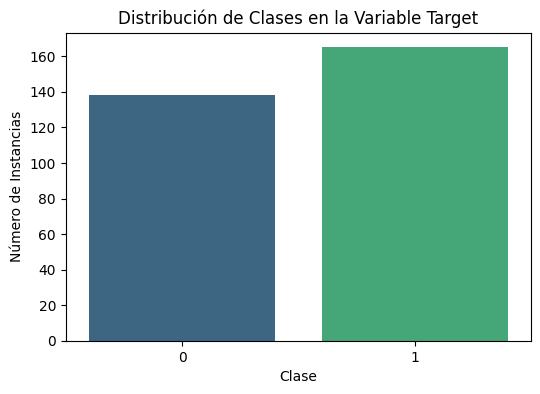

In [16]:
# Gráfico de barras o diagrama de pastel para visualizar el balanceo de las clases
plt.figure(figsize=(6, 4))
sns.countplot(x='output', data=heart_BI, palette='viridis')
plt.title('Distribución de Clases en la Variable Target')
plt.xlabel('Clase')
plt.ylabel('Número de Instancias')
plt.show()

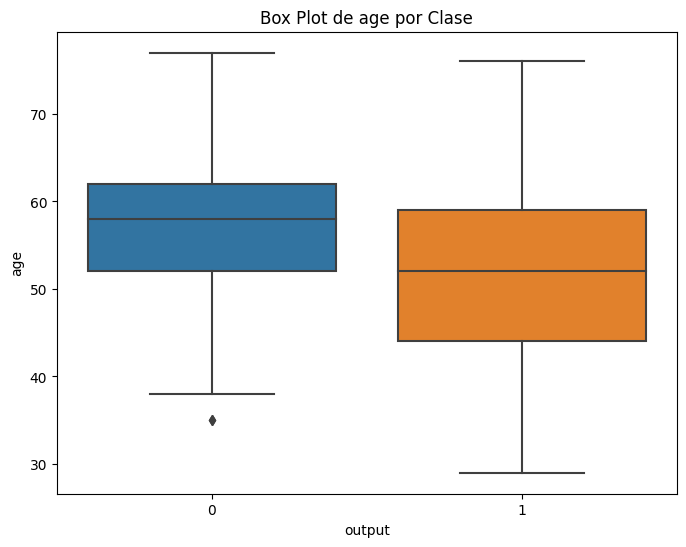

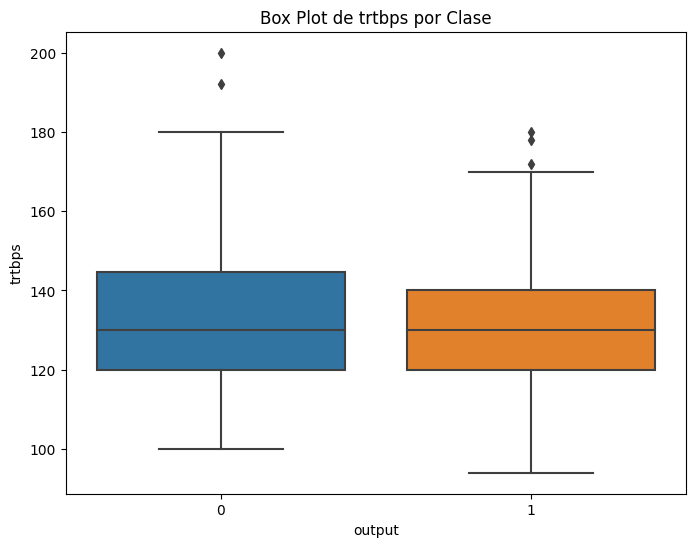

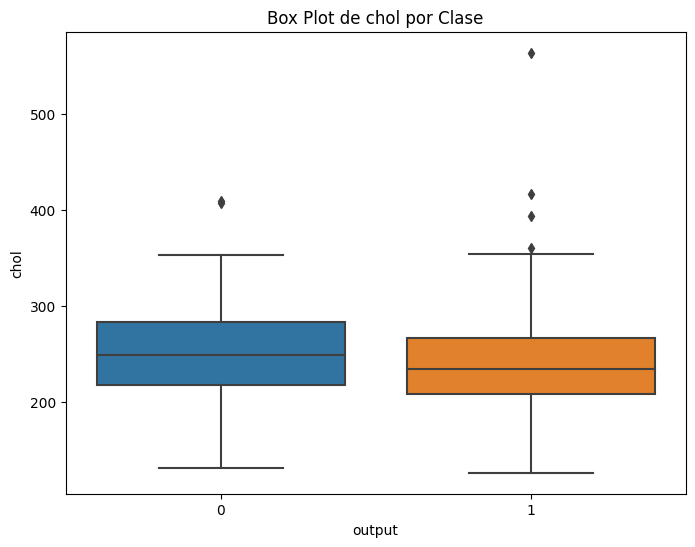

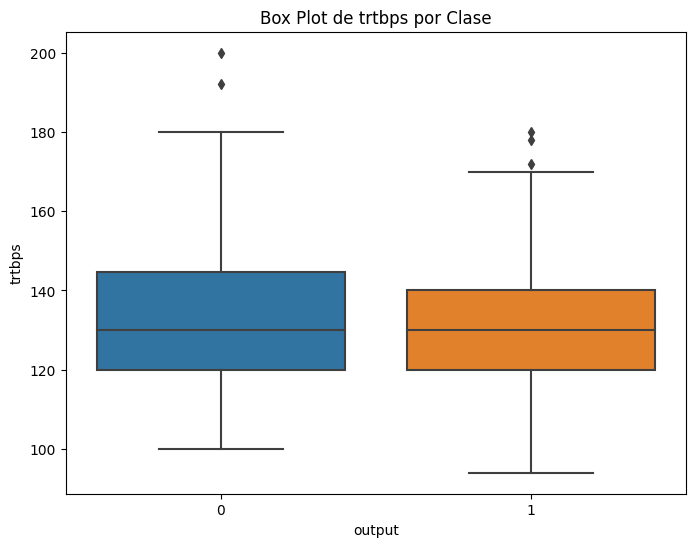

In [12]:
# Box plot por clase para variables seleccionadas
for feature in heart_BI[['age', 'trtbps', 'chol', 'trtbps', 'output']].drop('output', axis=1):
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='output', y=feature, data=heart_BI)
    plt.title(f'Box Plot de {feature} por Clase')
    plt.show()

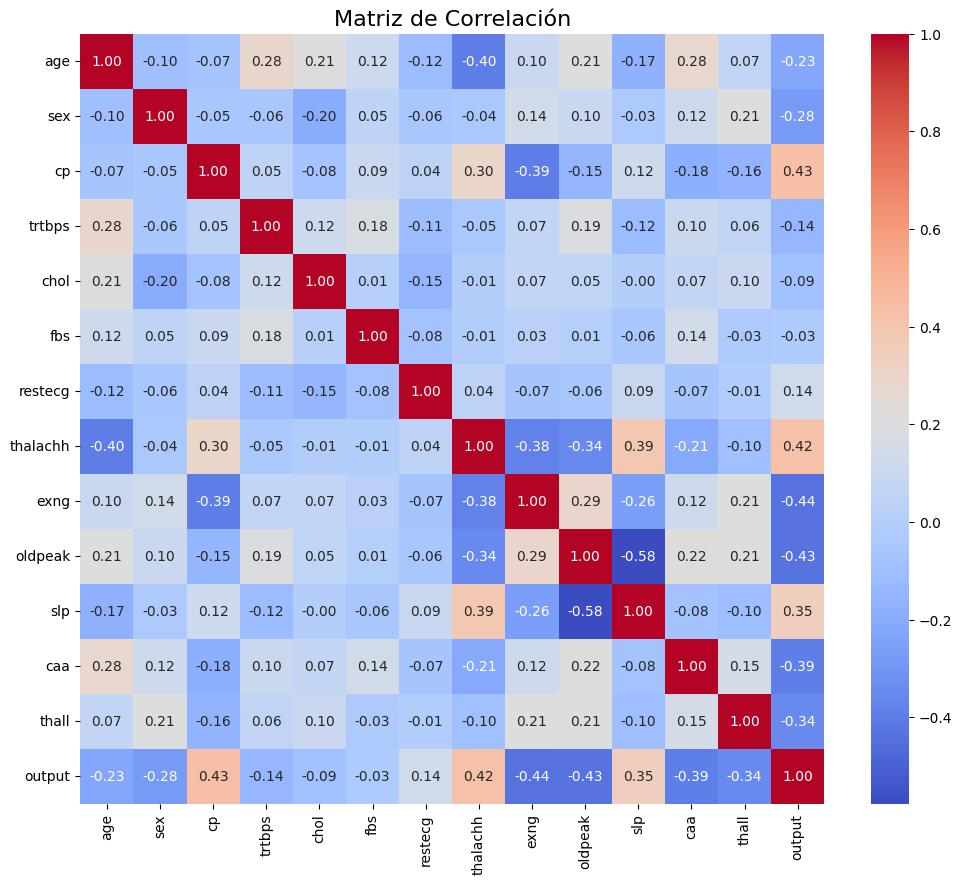

In [13]:
# Visualizar una matriz de correlación
# Calcular la matriz de correlación
corMatrix_heart_BI = heart_BI.corr()

# Aumentar el tamaño de la figura
plt.figure(figsize=(12, 10))

# Crear el mapa de calor
sns.heatmap(corMatrix_heart_BI, annot=True, cmap='coolwarm', fmt='.2f')

# Añadir título al gráfico
plt.title('Matriz de Correlación', fontsize=16)

# Mostrar el gráfico
plt.show()

In [14]:
# Obtener estadísticas descriptivas
descripcion_heart_BI = heart_BI.describe()
print(descripcion_heart_BI)

              age         sex          cp      trtbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg    thalachh        exng     oldpeak         slp         caa  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean     0.528053  149.646865    0.326733    1.039604    1.399340    0.729373   
std      0.525860   22.9051

In [15]:
# Obtener información general sobre el DataFrame
informacion_general_heart_BI = heart_BI.info()
print(informacion_general_heart_BI)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


### Split

In [18]:
# Dividir el conjunto de datos en conjuntos de entrenamiento y prueba
X = heart_BI.drop('output', axis=1)
y = heart_BI['output']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest

## Definición y entrenamiento del Modelo

### Sin optimización de parámetros

In [19]:
# Definir un modelo clasificador de Random Forest
rf_classifier_simple = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el modelo con el conjunto de entrenamiento
rf_classifier_simple.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_simple = rf_classifier_simple.predict(X_test)

# Evaluar el rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred_simple)
print(f'Accuracy: {accuracy:.2f}')

# Mostrar el informe de clasificación
print('Reporte de Performance del Modelo sin Optimización:\n', classification_report(y_test, y_pred_simple))

Accuracy: 0.84
Reporte de Performance del Modelo sin Optimización:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



#### Diferentes cortes entre Train y Test

In [27]:
# Definir diferentes proporciones de entrenamiento y prueba
test_sizes = [0.2, 0.3, 0.4]

# Crear un DataFrame para almacenar los resultados
results_df = pd.DataFrame(columns=['Proporción Test/Train', 'Accuracy'])

for test_size in test_sizes:
    # Dividir el conjunto de datos en conjuntos de entrenamiento y prueba
    X_train_TS, X_test_TS, y_train_TS, y_test_TS = train_test_split(X, y, test_size=test_size, random_state=42)

    # Crear y entrenar el modelo Random Forest
    rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_classifier.fit(X_train_TS, y_train_TS)

    # Realizar predicciones en el conjunto de prueba
    y_pred_TS = rf_classifier.predict(X_test_TS)

    # Evaluar el rendimiento del modelo
    accuracy = accuracy_score(y_test_TS, y_pred_TS)

    # Almacenar resultados en el DataFrame
    results_df = results_df.append({'Proporción Test/Train': f'{1 - test_size}/{test_size}', 'Accuracy': accuracy}, ignore_index=True)

    print(f'\nProporción Test/Train: {1 - test_size}/{test_size}')
    print(f'Accuracy: {accuracy:.2f}')
    print('Classification Report:\n', classification_report(y_test_TS, y_pred_TS))

# Imprimir la tabla de resultados con formato y resaltando valores máximos
styled_results = results_df.style.highlight_max(axis=0, color='green', subset='Accuracy').format({'Accuracy': '{:.2%}'})

# Mostrar la tabla final
styled_results

<ipython-input-27-d978e9469fd6>:22: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({'Proporción Test/Train': f'{1 - test_size}/{test_size}', 'Accuracy': accuracy}, ignore_index=True)



Proporción Test/Train: 0.8/0.2
Accuracy: 0.84
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



<ipython-input-27-d978e9469fd6>:22: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({'Proporción Test/Train': f'{1 - test_size}/{test_size}', 'Accuracy': accuracy}, ignore_index=True)



Proporción Test/Train: 0.7/0.3
Accuracy: 0.82
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        41
           1       0.84      0.84      0.84        50

    accuracy                           0.82        91
   macro avg       0.82      0.82      0.82        91
weighted avg       0.82      0.82      0.82        91


Proporción Test/Train: 0.6/0.4
Accuracy: 0.84
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81        52
           1       0.86      0.86      0.86        70

    accuracy                           0.84       122
   macro avg       0.83      0.83      0.83       122
weighted avg       0.84      0.84      0.84       122



<ipython-input-27-d978e9469fd6>:22: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({'Proporción Test/Train': f'{1 - test_size}/{test_size}', 'Accuracy': accuracy}, ignore_index=True)


,Proporción Test/Train,Accuracy
0,0.8/0.2,83.61%
1,0.7/0.3,82.42%
2,0.6/0.4,83.61%


### Con optimización de parámetros - GridSearch

* n_estimators: Número de árboles en el bosque. Aumentar este valor generalmente mejora el rendimiento del modelo, pero también aumenta el costo computacional.

* max_depth: La profundidad máxima de los árboles. Limitar la profundidad ayuda a prevenir el sobreajuste.

* min_samples_split: El número mínimo de muestras requeridas para dividir un nodo interno.

* min_samples_leaf: El número mínimo de muestras requeridas para estar en un nodo hoja.

In [21]:
# Definición de un modelo clasificador de Random Forest
rf_classifier = RandomForestClassifier(random_state=42)

# Definir los hiperparámetros a ajustar y sus posibles valores
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Configurar la búsqueda grid con validación cruzada (cross-validation)
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid,
                           cv=5, scoring='accuracy')

# Realizar la búsqueda grid en el conjunto de entrenamiento
grid_search.fit(X_train, y_train)

# Obtener los mejores hiperparámetros encontrados
best_params = grid_search.best_params_
print('Mejores hiperparámetros:', best_params)

# Utilizar el modelo con los mejores hiperparámetros para hacer predicciones en el conjunto de prueba
best_rf_classifier = grid_search.best_estimator_
y_pred_GS = best_rf_classifier.predict(X_test)

# Evaluar el rendimiento del modelo con los mejores hiperparámetros
accuracy = accuracy_score(y_test, y_pred_GS)
print(f'Accuracy con mejores hiperparámetros: {accuracy:.2f}')

# Mostrar el informe de clasificación
print('Reporte de Performance del Modelo con Optimización GS:\n', classification_report(y_test, y_pred_GS))

Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}
Accuracy con mejores hiperparámetros: 0.85
Reporte de Performance del Modelo con Optimización GS:
               precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

